   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 773.7/773.7 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.7/418.7 kB 23.9 MB/s eta 0:00:00

--- 1. SOLIS: AUGŠUPIELĀDĒT LOKĀCIJU CSV FAILU ---
Lūdzu, augšupielādējiet CSV failu ar kolonnām: 'id' un 'assigned_location'.


Saving lclc_manual_location_table.csv to lclc_manual_location_table.csv
Veiksmīgi integrēti lokāciju dati: reģistrēti 251 ieraksti.

Lejupielādē un inicializē latviešu valodas Stanza modeli...


INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/resources.json
INFO:stanza:Downloading these customized packages for language: lv (Latvian)...
| Processor | Package       |
-----------------------------
| tokenize  | lvtb          |
| pos       | lvtb_nocharlm |
| lemma     | lvtb_nocharlm |
| pretrain  | conll17       |



INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/lv/tokenize/lvtb.pt


INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/lv/pos/lvtb_nocharlm.pt


INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/lv/lemma/lvtb_nocharlm.pt


INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/lv/pretrain/conll17.pt
INFO:stanza:Finished downloading models and saved to /root/.cache/stanza/1.11.0/resources



--- 2. SOLIS: AUGŠUPIELĀDĒT ZIP ARHĪVU ---
Lūdzu, augšupielādējiet ZIP arhīvu, kas satur skrejlapu .txt failus.


Saving LCLC_1934-1940_only_unique_text_leaflets.zip to LCLC_1934-1940_only_unique_text_leaflets.zip
Veiksmīgi ekstrahēti 251 teksta faili empīriskajai analīzei.

Uzsākta 251 failu apstrāde...
Apstrādāti 10/251 faili... iekļauti analīzē: 10
Apstrādāti 20/251 faili... iekļauti analīzē: 20
Apstrādāti 30/251 faili... iekļauti analīzē: 30
Apstrādāti 40/251 faili... iekļauti analīzē: 40
Apstrādāti 50/251 faili... iekļauti analīzē: 50
Apstrādāti 60/251 faili... iekļauti analīzē: 60
Apstrādāti 70/251 faili... iekļauti analīzē: 70
Apstrādāti 80/251 faili... iekļauti analīzē: 80
Apstrādāti 90/251 faili... iekļauti analīzē: 90
Apstrādāti 100/251 faili... iekļauti analīzē: 100
Apstrādāti 110/251 faili... iekļauti analīzē: 110
Apstrādāti 120/251 faili... iekļauti analīzē: 118
Apstrādāti 130/251 faili... iekļauti analīzē: 128
Apstrādāti 140/251 faili... iekļauti analīzē: 138
Apstrādāti 150/251 faili... iekļauti analīzē: 148
Apstrādāti 160/251 faili... iekļauti analīzē: 157
Apstrādāti 170/251 faili..

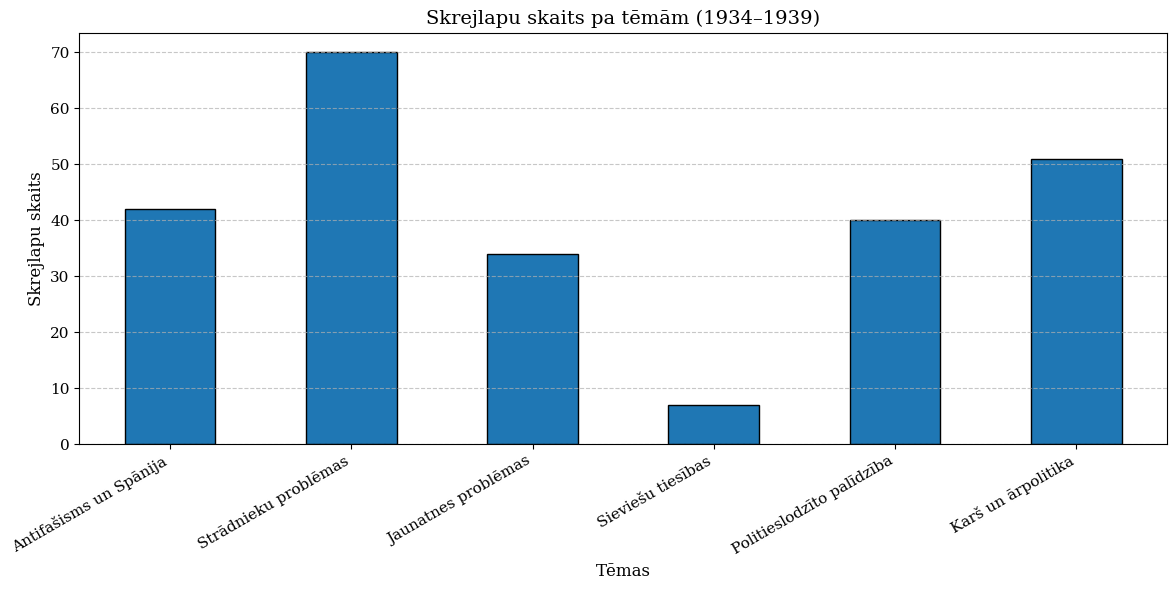

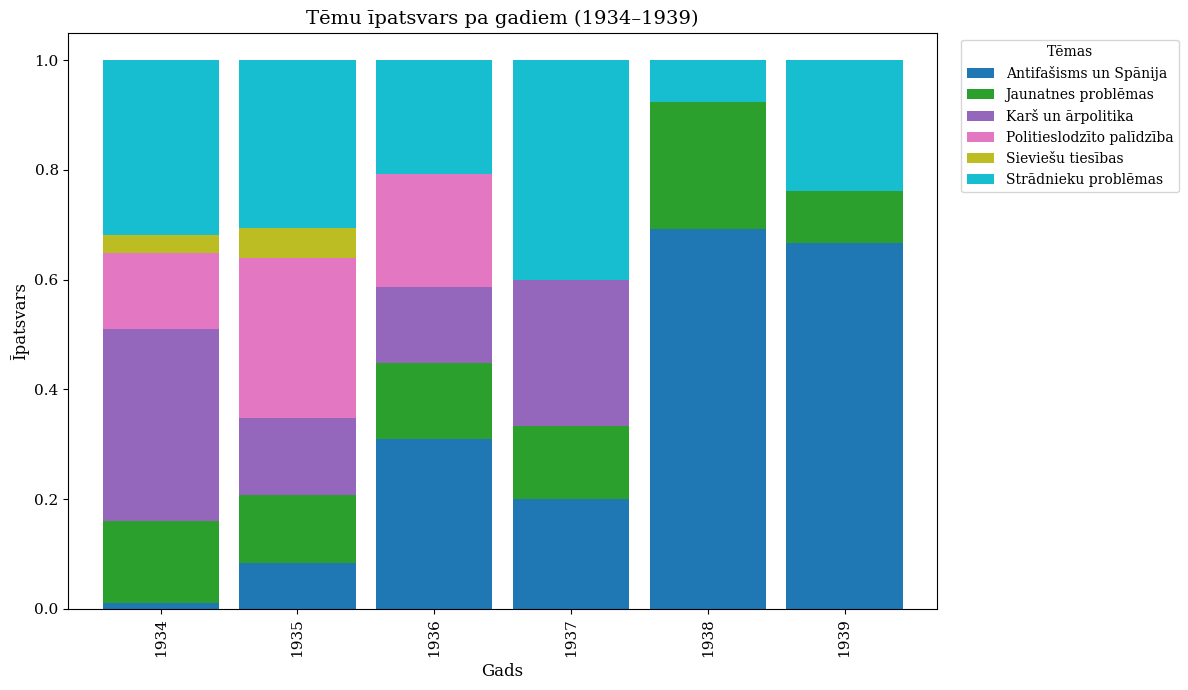

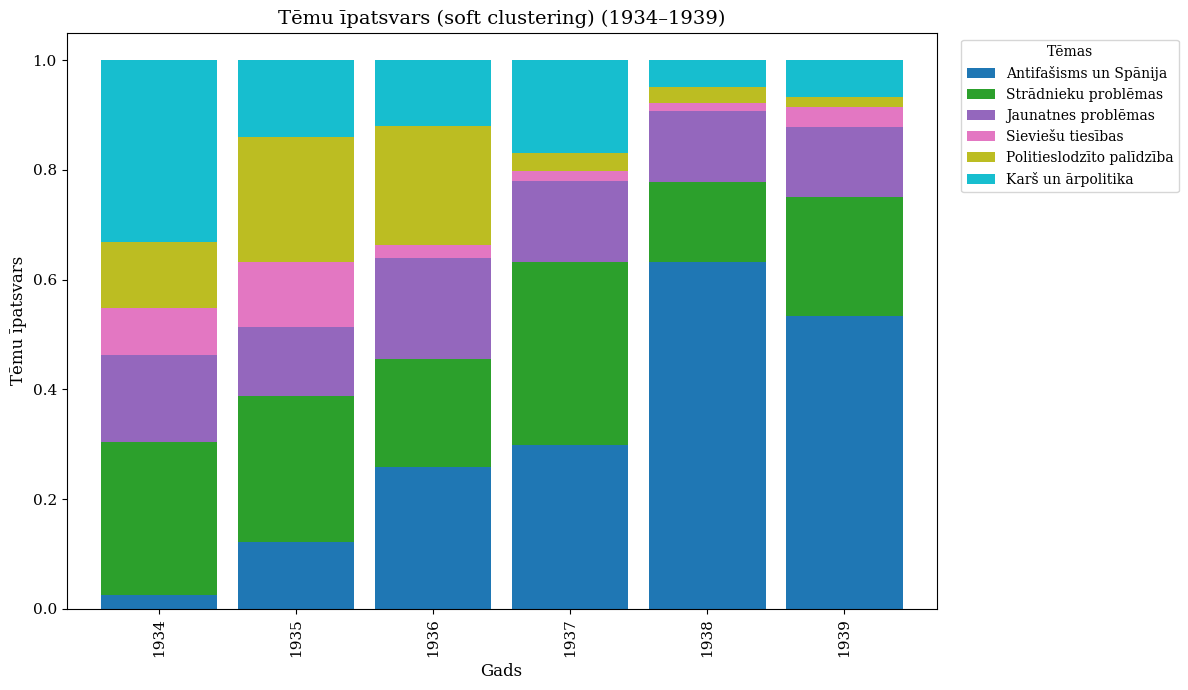

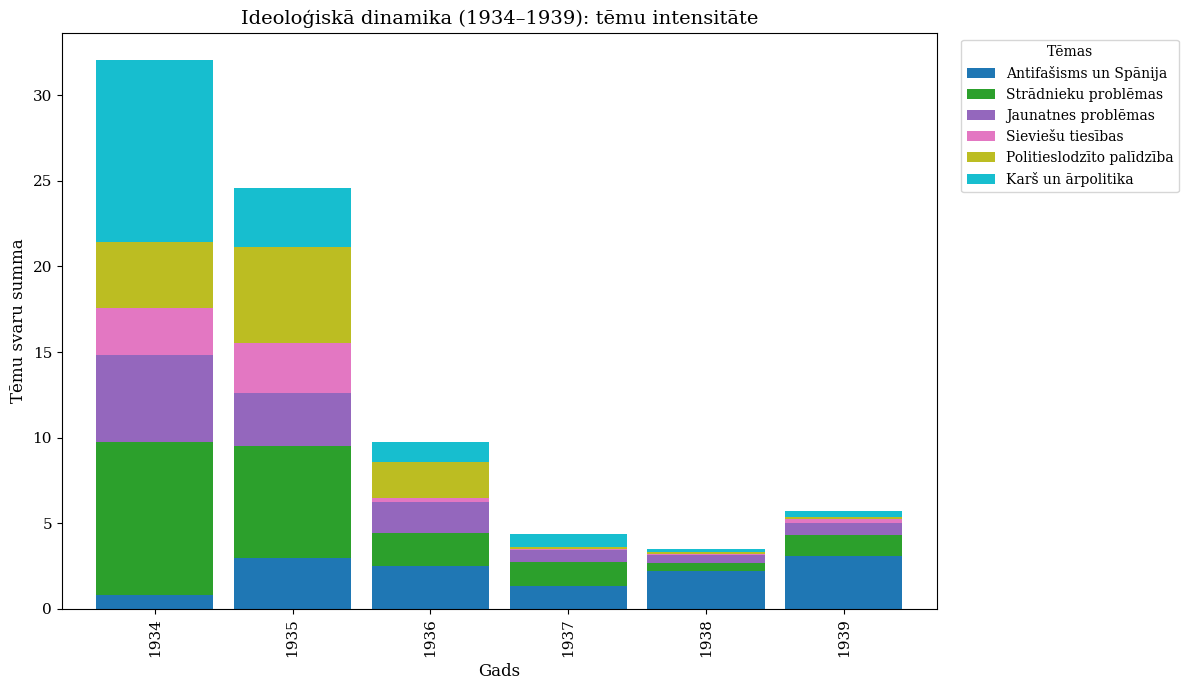

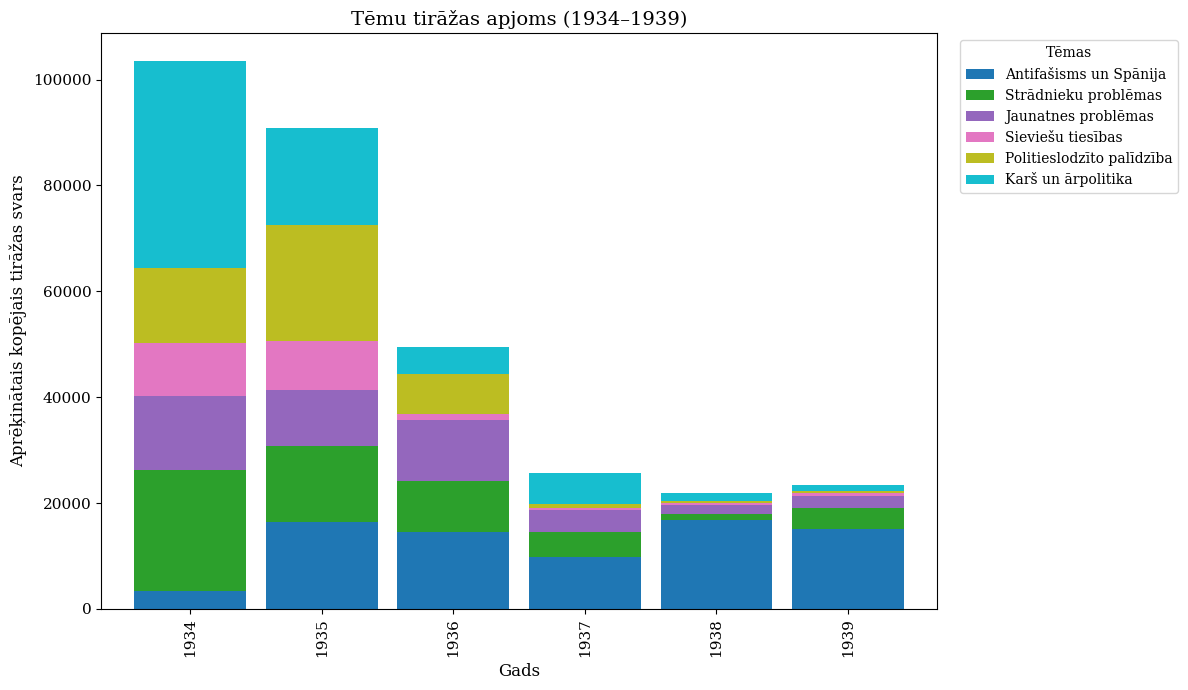


Apreķina 'Elbow method' kļūdas...


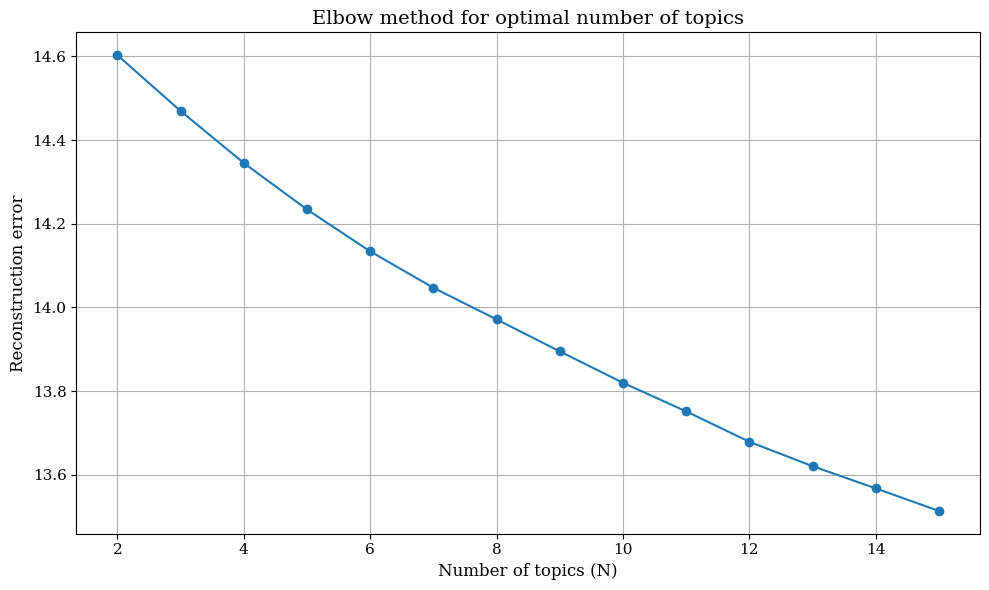

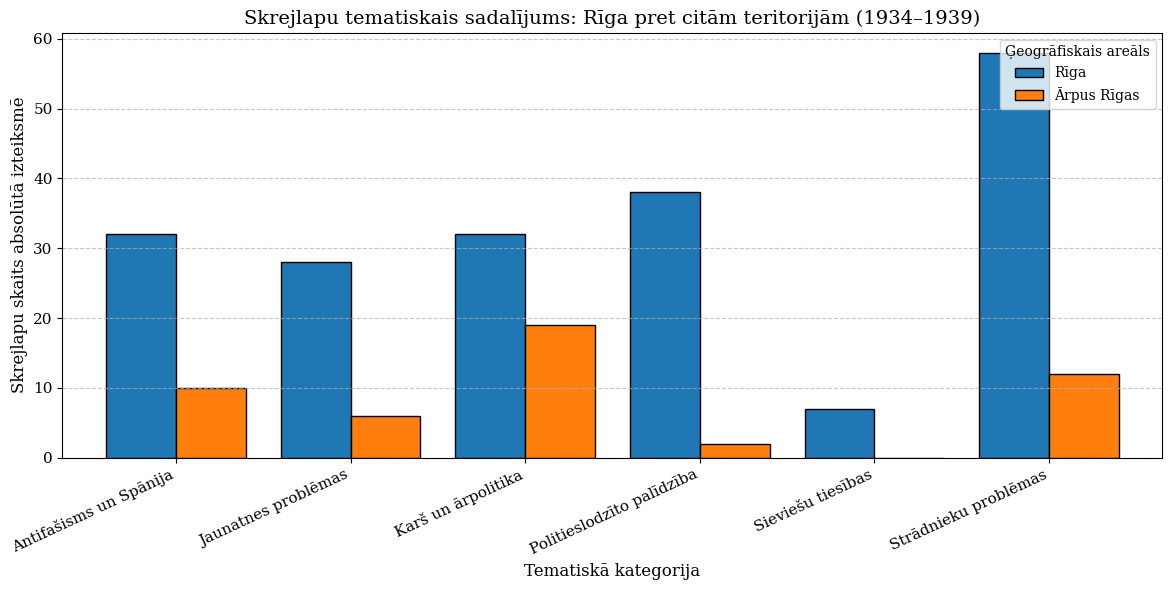

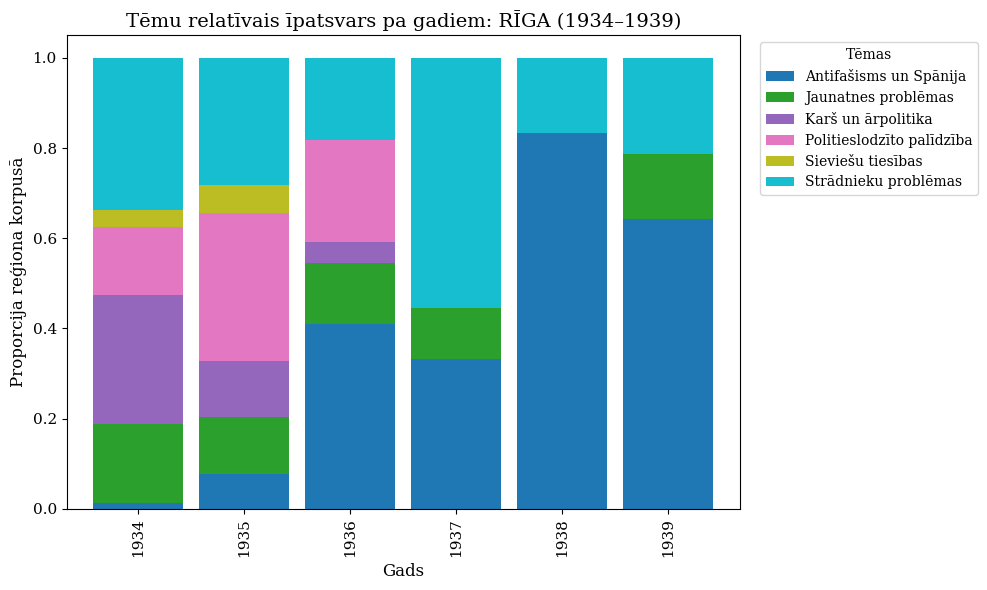

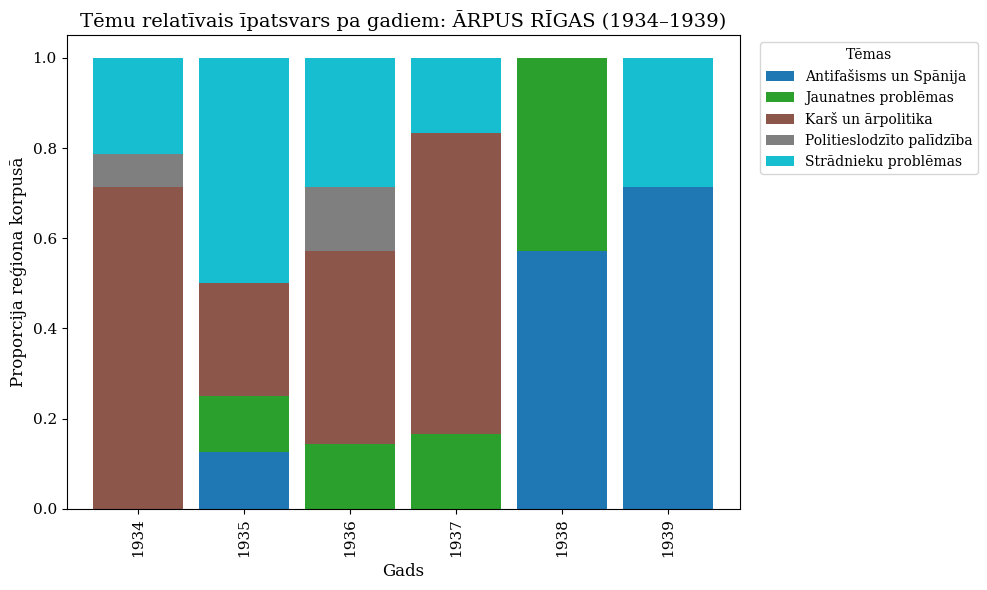


[LEMMATIZATION CHECK] FILE: lclc-n082-LKP_CK-5000-[…1934-11-07].txt

[RAW TEXT SAMPLE]
id: 82
file_name: lclc-n082-LKP_CK-5000-[…1934-11-07].txt
title: LKP CK lapiņa Lielās Oktobra sociālistiskās revolūcijas 17. gadadienā, ar aicinājumu uz cīņu par Padomju Latviju
author: LKP CK
date: […1934-11-07]
print_run: 5000
typography_name: Spartaks
production_method: typographic
original_langu...

[CLEAN TEXT SAMPLE]
cīņa uzvara zeme proletārietis savienoties latvija strādeieks darba zemnieks kareivģis jaunatne kalpotājs sociālists organīzacija biedri izvērst oktobris svētki novembris plašs latvija proletariāta kaujiniecisks spēks mobilizācija ulmanis fašists diktatūra karš sprs aizsardzība revolucionārs izeja k...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# -*- coding: utf-8 -*-
"""lemmatized_leaflet_tfidf_topic_modeling_nmf_1934_1939_full.ipynb

Automatically generated by Colab.
"""

# =======================
# 1. Install libraries
# =======================
!pip install stanza scikit-learn pandas matplotlib numpy chardet --quiet

# =======================
# 2. Imports
# =======================
import os
import re
import io
import zipfile
import chardet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import stanza

from google.colab import files
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

# =======================
# 3. Matplotlib style for thesis
# =======================
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "Times", "DejaVu Serif"]
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 10

# =======================
# 4. Lokāciju datu augšupielāde (CSV)
# =======================
print("\n--- 1. SOLIS: AUGŠUPIELĀDĒT LOKĀCIJU CSV FAILU ---")
print("Lūdzu, augšupielādējiet CSV failu ar kolonnām: 'id' un 'assigned_location'.")
uploaded_csv = files.upload()

if not uploaded_csv:
    raise SystemExit("Kritērijs nav izpildīts: Lokāciju CSV fails netika augšupielādēts.")

csv_name = next(iter(uploaded_csv.keys()))
raw_data = uploaded_csv[csv_name]

loc_df = None
for sep in ['\t', ',', ';']:
    try:
        temp_df = pd.read_csv(io.BytesIO(raw_data), sep=sep)
        temp_df.columns = temp_df.columns.str.strip().str.lower()

        if 'id' in temp_df.columns and 'assigned_location' in temp_df.columns:
            loc_df = temp_df
            break
    except Exception:
        continue

if loc_df is None:
    debug_df = pd.read_csv(io.BytesIO(raw_data))
    print("\nATRASTĀS KOLONNAS FAILĀ:", debug_df.columns.tolist())
    raise ValueError("Datu struktūras kļūda: CSV failā trūkst kolonnu 'id' un/vai 'assigned_location'.")

print(f"Veiksmīgi integrēti lokāciju dati: reģistrēti {len(loc_df)} ieraksti.")

# =======================
# 5. Inicializēt Stanza NLP modeli
# =======================
print("\nLejupielādē un inicializē latviešu valodas Stanza modeli...")
stanza.download("lv", processors="tokenize,pos,lemma")

nlp = stanza.Pipeline(
    "lv",
    processors="tokenize,pos,lemma",
    use_gpu=True,
    logging_level="WARN"
)

# =======================
# 6. Tekstu korpusa augšupielāde (ZIP)
# =======================
print("\n--- 2. SOLIS: AUGŠUPIELĀDĒT ZIP ARHĪVU ---")
print("Lūdzu, augšupielādējiet ZIP arhīvu, kas satur skrejlapu .txt failus.")
uploaded_zip = files.upload()

if not uploaded_zip:
    raise SystemExit("Kritērijs nav izpildīts: ZIP arhīvs netika augšupielādēts.")

zip_name = next(iter(uploaded_zip.keys()))
extract_dir = "leaflets_zip"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(io.BytesIO(uploaded_zip[zip_name]), "r") as zf:
    zf.extractall(extract_dir)

text_files = [os.path.join(extract_dir, f) for f in os.listdir(extract_dir) if f.lower().endswith(".txt")]
print(f"Veiksmīgi ekstrahēti {len(text_files)} teksta faili empīriskajai analīzei.")

# =======================
# 7. Konfigurācija
# =======================
TARGET_YEARS = list(range(1934, 1940))
N_TOPICS = 6
TOP_WORDS_PER_TOPIC = 15

LATVIAN_STOP_LEMMAS = set("un ir būt tikt kļūt par lai kas bet arī kā tas šis pie pret vai kad tad tik ar no uz mēs jūs viņš viņa kurš kāds viss jo gan vēl jau pat kurp ne nav ļoti tikai nekā taču man tevi sev savs".split())
META_STOP = {"id", "file_name", "title", "author", "date", "source", "text", "print_run", "typography_name", "production_method"}
STOPWORDS = LATVIAN_STOP_LEMMAS | META_STOP
ALLOWED_POS = {"NOUN", "VERB", "ADJ", "PROPN"}

topic_labels = {
    0: "Antifašisms un Spānija",
    1: "Strādnieku problēmas",
    2: "Jaunatnes problēmas",
    3: "Sieviešu tiesības",
    4: "Politieslodzīto palīdzība",
    5: "Karš un ārpolitika"
}

# =======================
# 8. Palīgfunkcijas
# =======================
def extract_id(full_text: str, fallback_filename: str = ""):
    m = re.search(r"(?im)^\s*id\s*:\s*(\d+)", full_text)
    if m: return int(m.group(1))
    m2 = re.search(r"^(\d+)", os.path.basename(fallback_filename))
    if m2: return int(m2.group(1))
    return None

def extract_text_block(full_text: str) -> str:
    parts = re.split(r"(?im)^\s*text\s*:\s*", full_text, maxsplit=1)
    return parts[1].strip() if len(parts) == 2 else full_text.strip()

def extract_year(full_text: str, fallback_filename: str = ""):
    for regex in [r"(?im)^\s*date\s*:\s*(.+)$", r"(?im)^\s*file_name\s*:\s*(.+)$"]:
        m = re.search(regex, full_text)
        if m:
            y = re.search(r"(19\d{2}|20\d{2})", m.group(1).strip())
            if y: return int(y.group(1))
    y3 = re.search(r"(19\d{2}|20\d{2})", fallback_filename)
    if y3: return int(y3.group(1))
    return None

def extract_print_run(full_text: str, fallback_filename: str = ""):
    m = re.search(r"(?im)^\s*print_run\s*:\s*(.+)$", full_text)
    if m:
        val = m.group(1).strip().lower()
        if val == "unk": return np.nan
        if re.fullmatch(r"\d+", val): return float(val)
    m2 = re.search(r"-(\d+)-[\[\.…]", os.path.basename(fallback_filename))
    if m2: return float(m2.group(1))
    return np.nan

def normalize_lemma(lemma: str) -> str:
    lemma = lemma.lower().strip()
    prefixes = {"sociāldemokr": "sociāldemokrāts", "fašist": "fašists", "komunist": "komunists",
                "strādniek": "strādnieks", "bezdarbniek": "bezdarbnieks", "kapitālist": "kapitālists", "buržuāz": "buržuāzija"}
    for pref, norm in prefixes.items():
        if lemma.startswith(pref): return norm
    return lemma

def lemmatize_text(full_text: str) -> str:
    text = extract_text_block(full_text)
    replacements = {r"s\.\-d\.?": " sociāldemokrāti ", r"1\.\s*maijs": " pirmais_maijs ",
                    r"7\.\s*novembris": " septītais_novembris ", r"padomju latvija": " padomju_latvija ",
                    r"politiskā pārvalde": " politiskā_pārvalde "}
    for pat, repl in replacements.items():
        text = re.sub(pat, repl, text, flags=re.IGNORECASE)

    if len(text) > 100000: text = text[:100000]
    doc = nlp(text)
    lemmas = [normalize_lemma(w.lemma or "") for s in doc.sentences for w in s.words
              if len(normalize_lemma(w.lemma or "")) > 2 and normalize_lemma(w.lemma or "") not in STOPWORDS
              and w.upos in ALLOWED_POS and re.fullmatch(r"[a-zāčēģīķļņšūž_]+", normalize_lemma(w.lemma or ""))]
    return " ".join(lemmas)

# =======================
# 9. Datu integrācija un priekšapstrāde
# =======================
data_rows, failed_rows = [], []
print(f"\nUzsākta {len(text_files)} failu apstrāde...")

for i, filepath in enumerate(text_files, start=1):
    try:
        with open(filepath, "r", encoding="utf-8", errors="replace") as f: raw_content = f.read()
        year = extract_year(raw_content, fallback_filename=filepath)
        doc_id = extract_id(raw_content, fallback_filename=filepath)

        if year not in TARGET_YEARS:
            failed_rows.append({"file_name": os.path.basename(filepath), "reason": "year_outside_target_or_missing"})
            continue

        clean_content = lemmatize_text(raw_content)
        if not clean_content.strip():
            failed_rows.append({"file_name": os.path.basename(filepath), "reason": "empty_after_lemmatization"})
            continue

        data_rows.append({"id": doc_id, "file_name": os.path.basename(filepath), "year": year,
                          "print_run": extract_print_run(raw_content, filepath), "raw_text": raw_content, "clean_text": clean_content})

        if i % 10 == 0 or i == len(text_files): print(f"Apstrādāti {i}/{len(text_files)} faili... iekļauti analīzē: {len(data_rows)}")
    except Exception as e:
        failed_rows.append({"file_name": os.path.basename(filepath), "reason": f"exception: {e}"})

df = pd.DataFrame(data_rows)
df['id'] = pd.to_numeric(df['id'], errors='coerce')
loc_df['id'] = pd.to_numeric(loc_df['id'], errors='coerce')
df = df.merge(loc_df, on='id', how='left')
df['assigned_location'] = df['assigned_location'].fillna('Nezināms')
df['region_category'] = df['assigned_location'].apply(lambda x: "Rīga" if str(x).strip() == "Rīga" else "Ārpus Rīgas")

failed_df = pd.DataFrame(failed_rows)
print(f"\nPētījumā iekļautie dokumenti: {len(df)}\nEkskludētie dokumenti: {len(failed_df)}")

# =======================
# 10. TF-IDF un NMF modelēšana
# =======================
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95)
X_tfidf = tfidf_vectorizer.fit_transform(df["clean_text"])
feature_names = tfidf_vectorizer.get_feature_names_out()

nmf_model = NMF(n_components=N_TOPICS, random_state=42, init="nndsvda", max_iter=1000)
W = nmf_model.fit_transform(X_tfidf)
H = nmf_model.components_

topic_summaries = [", ".join([feature_names[i] for i in topic.argsort()[::-1][:TOP_WORDS_PER_TOPIC]]) for topic in H]
df["topic_id"] = W.argmax(axis=1)
df["topic_score"] = W.max(axis=1)
df["topic_keywords"] = df["topic_id"].apply(lambda x: topic_summaries[x])
df["topic_label"] = df["topic_id"].map(topic_labels)

# =======================
# 11. VIZUALIZĀCIJAS (Vispārējās un Reģionālās)
# =======================
print("\nĢenerē analītiskās vizualizācijas...")

# Plot 1: Skrejlapu skaits pa tēmām
topic_counts = df["topic_id"].value_counts().sort_index()
topic_counts.index = [topic_labels[i] for i in topic_counts.index]

plt.figure(figsize=(12, 6))
topic_counts.plot(kind="bar", edgecolor="black")
plt.title("Skrejlapu skaits pa tēmām (1934–1939)")
plt.xlabel("Tēmas")
plt.ylabel("Skrejlapu skaits")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("01_documents_per_topic_1934_1939.png", dpi=600, bbox_inches="tight")
plt.show()

# Plot 2: Tēmu īpatsvars pa gadiem (Dominējošā tēma)
pivot_counts = df.groupby(["year", "topic_label"]).size().unstack(fill_value=0).reindex(TARGET_YEARS, fill_value=0)
pivot_pct = pivot_counts.div(pivot_counts.sum(axis=1).replace(0, 1), axis=0).fillna(0)
pivot_pct.plot(kind="bar", stacked=True, figsize=(12, 7), colormap="tab10", width=0.85, edgecolor="none")
plt.title("Tēmu īpatsvars pa gadiem (1934–1939)")
plt.xlabel("Gads")
plt.ylabel("Īpatsvars")
plt.legend(title="Tēmas", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("02_topic_share_by_year_1934_1939.png", dpi=600, bbox_inches="tight")
plt.show()

# Plot 3: Tēmu īpatsvars (Soft clustering)
topic_weights_df = pd.DataFrame(W, columns=[topic_labels[i] for i in range(N_TOPICS)])
topic_weights_df["year"] = df["year"].values
soft_clustering = topic_weights_df.groupby("year").sum().reindex(TARGET_YEARS, fill_value=0)
soft_clustering_pct = soft_clustering.div(soft_clustering.sum(axis=1).replace(0, 1), axis=0).fillna(0)
soft_clustering_pct.plot(kind="bar", stacked=True, figsize=(12, 7), colormap="tab10", width=0.85, edgecolor="none")
plt.title("Tēmu īpatsvars (soft clustering) (1934–1939)")
plt.xlabel("Gads")
plt.ylabel("Tēmu īpatsvars")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Tēmas")
plt.tight_layout()
plt.savefig("03_soft_clustering_share_1934_1939.png", dpi=600, bbox_inches="tight")
plt.show()

# Plot 4: Absolūtā tēmu intensitāte
soft_clustering.plot(kind="bar", stacked=True, figsize=(12, 7), colormap="tab10", width=0.85, edgecolor="none")
plt.title("Ideoloģiskā dinamika (1934–1939): tēmu intensitāte")
plt.xlabel("Gads")
plt.ylabel("Tēmu svaru summa")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Tēmas")
plt.tight_layout()
plt.savefig("04_topic_intensity_absolute_1934_1939.png", dpi=600, bbox_inches="tight")
plt.show()

# Plot 5: Tēmu tirāžas apjoms (Print-run weighted)
df["print_run_filled"] = df["print_run"].fillna(df["print_run"].median())
topic_weights_weighted = pd.DataFrame(W, columns=[topic_labels[i] for i in range(N_TOPICS)]).multiply(df["print_run_filled"], axis=0)
topic_weights_weighted["year"] = df["year"].values
impact_data = topic_weights_weighted.groupby("year").sum().reindex(TARGET_YEARS, fill_value=0)
impact_data.plot(kind="bar", stacked=True, figsize=(12, 7), colormap="tab10", width=0.85, edgecolor="none")
plt.title("Tēmu tirāžas apjoms (1934–1939)")
plt.xlabel("Gads")
plt.ylabel("Aprēķinātais kopējais tirāžas svars")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Tēmas")
plt.tight_layout()
plt.savefig("05_topic_print_run_weighted_1934_1939.png", dpi=600, bbox_inches="tight")
plt.show()

# Plot 6: Elbow Method optimalam tēmu skaitam
n_range = range(2, 16)
reconstruction_errors = []
print("\nApreķina 'Elbow method' kļūdas...")
for n in n_range:
    nmf_test = NMF(n_components=n, init="nndsvda", random_state=42, max_iter=500).fit(X_tfidf)
    reconstruction_errors.append(nmf_test.reconstruction_err_)

plt.figure(figsize=(10, 6))
plt.plot(list(n_range), reconstruction_errors, marker="o")
plt.title("Elbow method for optimal number of topics")
plt.xlabel("Number of topics (N)")
plt.ylabel("Reconstruction error")
plt.grid(True)
plt.tight_layout()
plt.savefig("06_nmf_elbow_1934_1939.png", dpi=600, bbox_inches="tight")
plt.show()

# Plot 7: Reģionālais sadalījums - Rīga vs Pārējā teritorija
region_topic_counts = df.groupby(['topic_label', 'region_category']).size().unstack(fill_value=0)
region_topic_counts.plot(kind="bar", figsize=(12, 6), edgecolor="black", width=0.8, color=["#1f77b4", "#ff7f0e"])
plt.title("Skrejlapu tematiskais sadalījums: Rīga pret citām teritorijām (1934–1939)")
plt.xlabel("Tematiskā kategorija")
plt.ylabel("Skrejlapu skaits absolūtā izteiksmē")
plt.xticks(rotation=25, ha="right")
plt.legend(title="Ģeogrāfiskais areāls", loc="upper right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("07_topics_by_region_comparison.png", dpi=600, bbox_inches="tight")
plt.show()

# Plot 8: Reģionālā dinamika – RĪGA
df_riga = df[df['region_category'] == 'Rīga']
if not df_riga.empty:
    pivot_riga = df_riga.groupby(["year", "topic_label"]).size().unstack(fill_value=0).reindex(TARGET_YEARS, fill_value=0)
    pivot_pct_riga = pivot_riga.div(pivot_riga.sum(axis=1).replace(0, 1), axis=0).fillna(0)
    pivot_pct_riga.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="tab10", width=0.85, edgecolor="none")
    plt.title("Tēmu relatīvais īpatsvars pa gadiem: RĪGA (1934–1939)")
    plt.xlabel("Gads")
    plt.ylabel("Proporcija reģiona korpusā")
    plt.legend(title="Tēmas", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig("08_topic_share_by_year_RIGA.png", dpi=600, bbox_inches="tight")
    plt.show()

# Plot 9: Reģionālā dinamika – ĀRPUS RĪGAS
df_not_riga = df[df['region_category'] == 'Ārpus Rīgas']
if not df_not_riga.empty:
    pivot_not_riga = df_not_riga.groupby(["year", "topic_label"]).size().unstack(fill_value=0).reindex(TARGET_YEARS, fill_value=0)
    pivot_pct_not_riga = pivot_not_riga.div(pivot_not_riga.sum(axis=1).replace(0, 1), axis=0).fillna(0)
    pivot_pct_not_riga.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="tab10", width=0.85, edgecolor="none")
    plt.title("Tēmu relatīvais īpatsvars pa gadiem: ĀRPUS RĪGAS (1934–1939)")
    plt.xlabel("Gads")
    plt.ylabel("Proporcija reģiona korpusā")
    plt.legend(title="Tēmas", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig("09_topic_share_by_year_NOT_RIGA.png", dpi=600, bbox_inches="tight")
    plt.show()

# =======================
# 12. Datu eksports un pārbaude
# =======================
def check_lemmatization_quality(search_query: str):
    found_row = df[df["file_name"].astype(str).str.contains(search_query, case=False, regex=False)]
    if found_row.empty: return
    row = found_row.iloc[0]
    print(f"\n[LEMMATIZATION CHECK] FILE: {row['file_name']}\n" + "=" * 70)
    print(f"\n[RAW TEXT SAMPLE]\n{row['raw_text'][:300]}...\n\n[CLEAN TEXT SAMPLE]\n{row['clean_text'][:300]}...")

check_lemmatization_quality("1934")

df.to_csv("leaflets_nmf_topics_1934_1939_regions.csv", index=False, encoding="utf-8-sig")
failed_df.to_csv("leaflets_excluded_diagnostics.csv", index=False, encoding="utf-8-sig")

pd.DataFrame({"topic_id": list(range(N_TOPICS)), "topic_label": [topic_labels[i] for i in range(N_TOPICS)], "top_keywords": topic_summaries}).to_csv("nmf_topic_keywords_1934_1939.csv", index=False, encoding="utf-8-sig")

files.download("leaflets_nmf_topics_1934_1939_regions.csv")
files.download("nmf_topic_keywords_1934_1939.csv")
files.download("leaflets_excluded_diagnostics.csv")

In [2]:
# ======================================================
# 16. NMF TĒMU ATSLĒGVĀRDU (TOP WORDS) IZVADE
# ======================================================
import pandas as pd
from IPython.display import display

print("\n=== NMF MODEĻA IDENTIFICĒTIE ATSLĒGVĀRDI KATRAI TĒMAI ===")
print("Šie ir vārdi, ar kuru palīdzību algoritms 'saprata' teksta piederību klasterim.")
print("=" * 90)

# Izvadām kā formātētu tekstu
for topic_idx in range(N_TOPICS):
    label = topic_labels.get(topic_idx, f"Tēma {topic_idx}")
    top_words = topic_summaries[topic_idx]

    print(f"TĒMA {topic_idx} | {label.upper()}")
    print(f"Vārdi: {top_words}")
    print("-" * 90)

# Izveidojam smuku tabulu vizuālai pārskatāmībai Notebook vidē
keywords_df = pd.DataFrame({
    "Tēmas ID": list(range(N_TOPICS)),
    "Cilvēka dotais nosaukums": [topic_labels[i] for i in range(N_TOPICS)],
    "Modeļa top 10 atslēgvārdi": topic_summaries
})

print("\nTabulas skats:")
display(keywords_df)


=== NMF MODEĻA IDENTIFICĒTIE ATSLĒGVĀRDI KATRAI TĒMAI ===
Šie ir vārdi, ar kuru palīdzību algoritms 'saprata' teksta piederību klasterim.
TĒMA 0 | ANTIFAŠISMS UN SPĀNIJA
Vārdi: tauta, latvija, fašists, spānija, brīvība, ulmanis, sprs, karš, vācija, latvis, valdība, miers, valsts, hitlers, fašisms
------------------------------------------------------------------------------------------
TĒMA 1 | STRĀDNIEKU PROBLĒMAS
Vārdi: strādnieks, darbs, alga, arodbiedrība, fašists, valdība, cīņa, uzņēmējs, streiks, bezdarbnieks, stāvoklis, prasība, darbs alga, prasīt, biedrs
------------------------------------------------------------------------------------------
TĒMA 2 | JAUNATNES PROBLĒMAS
Vārdi: jaunatne, skola, darbs, jaunietis, darbs jaunatne, skolnieks, cīņa, latvija, fašists, izglītība, lauks, revolucionārs, darbs jaunietis, strādnieks, organizācija
------------------------------------------------------------------------------------------
TĒMA 3 | SIEVIEŠU TIESĪBAS
Vārdi: sieviete, darbs s

,Tēmas ID,Cilvēka dotais nosaukums,Modeļa top 10 atslēgvārdi
0,0,Antifašisms un Spānija,"tauta, latvija, fašists, spānija, brīvība, ulm..."
1,1,Strādnieku problēmas,"strādnieks, darbs, alga, arodbiedrība, fašists..."
2,2,Jaunatnes problēmas,"jaunatne, skola, darbs, jaunietis, darbs jauna..."
3,3,Sieviešu tiesības,"sieviete, darbs sieviete, darbs, bērns, māte, ..."
4,4,Politieslodzīto palīdzība,"sarkans palīdzība, ieslodzīt, cietums, palīdzī..."
5,5,Karš un ārpolitika,"karš, buržuāzija, sprs, padomju, strādnieks, s..."


In [ ]:
print("\n--- 3. SOLIS: AUGŠUPIELĀDĒT MANUĀLĀS KLASIFIKĀCIJAS CSV FAILU ---")
print("Lūdzu, augšupielādējiet CSV failu ar kolonnām: 'id' un 'manual_topic'.")
uploaded_manual = files.upload()


Veiksmīgi sapludināti 244 dokumenti validācijas analīzei.

--- VALIDĀCIJAS REZULTĀTI ---
Vispārējā klasifikācijas precizitāte (Accuracy, izslēdzot 'Other'): 0.7254 (72.5%)

Detalizēts klasifikācijas ziņojums:

                           precision    recall  f1-score   support

   Antifašisms un Spānija       0.12      0.83      0.21         6
      Jaunatnes problēmas       0.97      0.82      0.89        40
       Karš un ārpolitika       0.59      0.46      0.52        65
Politieslodzīto palīdzība       0.90      0.95      0.92        38
        Sieviešu tiesības       0.86      1.00      0.92         6
     Strādnieku problēmas       0.96      0.75      0.84        89

                 accuracy                           0.73       244
                macro avg       0.73      0.80      0.72       244
             weighted avg       0.83      0.73      0.76       244



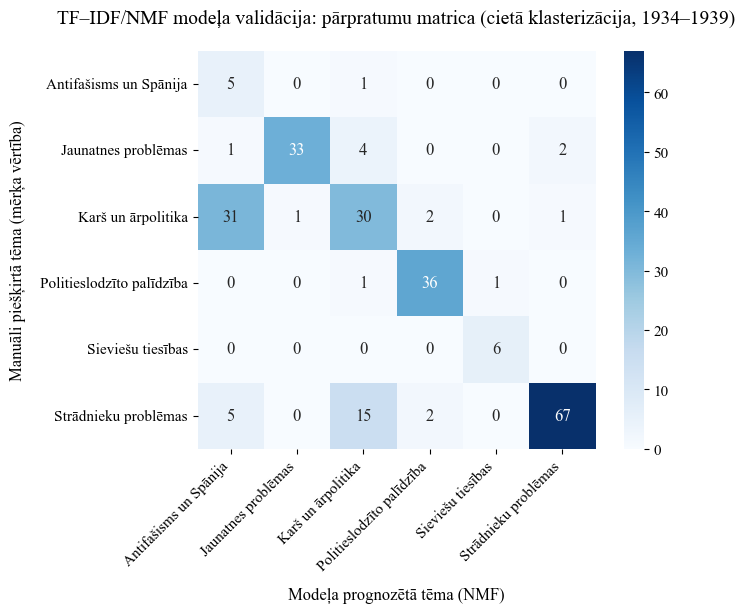

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
# =======================
# 13. NMF modeļa precizitātes empīriskā validācija (Hard Clustering vs Ground Truth)
# =======================
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from matplotlib import font_manager
font_manager.fontManager.addfont('/content/times.ttf')
matplotlib.rcParams['font.family'] = 'Times New Roman'

if not uploaded_manual:
    raise SystemExit("Kritērijs nav izpildīts: Manuālās klasifikācijas CSV fails netika augšupielādēts.")

csv_manual_name = next(iter(uploaded_manual.keys()))
raw_manual_data = uploaded_manual[csv_manual_name]

# Robustas datu nolasīšanas loģika
manual_df = None
for sep in ['\t', ',', ';']:
    try:
        temp_df = pd.read_csv(io.BytesIO(raw_manual_data), sep=sep)
        temp_df.columns = temp_df.columns.str.strip().str.lower()
        if 'id' in temp_df.columns and 'manual_topic' in temp_df.columns:
            manual_df = temp_df
            break
    except Exception:
        continue

if manual_df is None:
    raise ValueError("Datu struktūras kļūda: Faila struktūra netika atpazīta. Pārbaudiet kolonnu nosaukumus.")

# Datu tipu standartizācija sapludināšanai
manual_df['id'] = pd.to_numeric(manual_df['id'], errors='coerce')
manual_df['manual_topic'] = manual_df['manual_topic'].astype(str).str.strip()

# Definējam kartēšanas vārdnīcu: no jūsu angļu kategorijām uz modeļa latviešu tēmām
# Piezīme: "Other" tiks klasificēts kā "Cits", ko modelis dabiski neatrod
manual_to_model_map = {
    "Labour": "Strādnieku problēmas",
    "Youth": "Jaunatnes problēmas",
    "Women": "Sieviešu tiesības",
    "Aid": "Politieslodzīto palīdzība",
    "Foreign/War": "Karš un ārpolitika",
    "Spain": "Antifašisms un Spānija",
    "Other": "Cits (Nav modelī)"
}

manual_df['mapped_manual_topic'] = manual_df['manual_topic'].map(manual_to_model_map).fillna("Nezināms")

# Sapludinām ar galveno datu rāmi
validation_df = df.merge(manual_df[['id', 'mapped_manual_topic', 'manual_topic']], on='id', how='inner')

print(f"\nVeiksmīgi sapludināti {len(validation_df)} dokumenti validācijas analīzei.")

# Filtrējam ārā "Other" un "Nezināms" objektīvai modeļa veiktspējas mērīšanai
# (Tā kā NMF modelis neparedz tēmu "Other", tās iekļaušana mākslīgi samazinātu precizitāti)
strict_validation_df = validation_df[~validation_df['mapped_manual_topic'].isin(["Cits (Nav modelī)", "Nezināms"])]

y_true = strict_validation_df['mapped_manual_topic']
y_pred = strict_validation_df['topic_label']

# Aprēķinām metrikas
accuracy = accuracy_score(y_true, y_pred)
print(f"\n--- VALIDĀCIJAS REZULTĀTI ---")
print(f"Vispārējā klasifikācijas precizitāte (Accuracy, izslēdzot 'Other'): {accuracy:.4f} ({accuracy*100:.1f}%)")
print("\nDetalizēts klasifikācijas ziņojums:\n")
print(classification_report(y_true, y_pred, zero_division=0))

# =======================
# 14. Konfūzijas matricas vizualizācija
# =======================
labels = sorted(list(set(y_true) | set(y_pred)))
cm = confusion_matrix(y_true, y_pred, labels=labels)

import matplotlib
matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['font.size'] = 12
matplotlib.rcParams['svg.fonttype'] = 'none'

# A4 lappuses platums mīnus malas = aptuveni 16 cm
fig_width_cm = 20
fig_height_cm = 16
fig, ax = plt.subplots(figsize=(fig_width_cm/2.54, fig_height_cm/2.54))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            annot_kws={"size": 12}, ax=ax, square=True,
            cbar_kws={"shrink": 1})

ax.set_title("TF–IDF/NMF modeļa validācija: pārpratumu matrica (cietā klasterizācija, 1934–1939)", pad=20)
ax.set_xlabel("Modeļa prognozētā tēma (NMF)", labelpad=10)
ax.set_ylabel("Manuāli piešķirtā tēma (mērķa vērtība)", labelpad=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig("10_confusion_matrix_validation.svg", format='svg', bbox_inches="tight")
plt.savefig("10_confusion_matrix_validation.png", dpi=600, bbox_inches="tight")
plt.savefig("10_confusion_matrix_validation.pdf", format='pdf', bbox_inches="tight")

plt.show()
#files.download("10_confusion_matrix_validation.svg")
files.download("10_confusion_matrix_validation.pdf")


Veiksmīgi sapludināti 244 dokumenti validācijas analīzei.

--- VALIDĀCIJAS REZULTĀTI ---
Vispārējā klasifikācijas precizitāte (Accuracy, izslēdzot 'Other'): 0.7254 (72.5%)

Detalizēts klasifikācijas ziņojums:

                           precision    recall  f1-score   support

   Antifašisms un Spānija       0.12      0.83      0.21         6
      Jaunatnes problēmas       0.97      0.82      0.89        40
       Karš un ārpolitika       0.59      0.46      0.52        65
Politieslodzīto palīdzība       0.90      0.95      0.92        38
        Sieviešu tiesības       0.86      1.00      0.92         6
     Strādnieku problēmas       0.96      0.75      0.84        89

                 accuracy                           0.73       244
                macro avg       0.73      0.80      0.72       244
             weighted avg       0.83      0.73      0.76       244



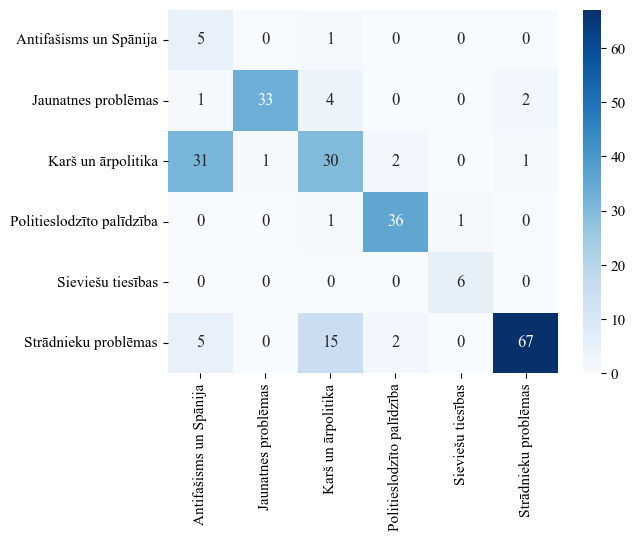

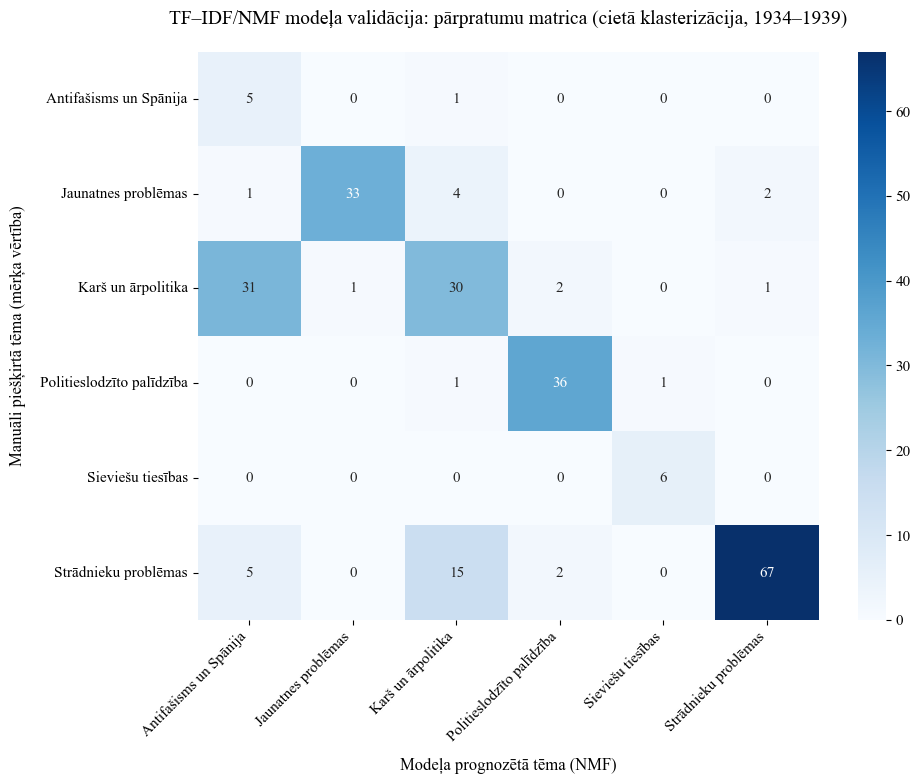

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
# =======================
# 13. NMF modeļa precizitātes empīriskā validācija (Hard Clustering vs Ground Truth)
# =======================
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from matplotlib import font_manager
font_manager.fontManager.addfont('/content/times.ttf')
matplotlib.rcParams['font.family'] = 'Times New Roman'

if not uploaded_manual:
    raise SystemExit("Kritērijs nav izpildīts: Manuālās klasifikācijas CSV fails netika augšupielādēts.")

csv_manual_name = next(iter(uploaded_manual.keys()))
raw_manual_data = uploaded_manual[csv_manual_name]

# Robustas datu nolasīšanas loģika
manual_df = None
for sep in ['\t', ',', ';']:
    try:
        temp_df = pd.read_csv(io.BytesIO(raw_manual_data), sep=sep)
        temp_df.columns = temp_df.columns.str.strip().str.lower()
        if 'id' in temp_df.columns and 'manual_topic' in temp_df.columns:
            manual_df = temp_df
            break
    except Exception:
        continue

if manual_df is None:
    raise ValueError("Datu struktūras kļūda: Faila struktūra netika atpazīta. Pārbaudiet kolonnu nosaukumus.")

# Datu tipu standartizācija sapludināšanai
manual_df['id'] = pd.to_numeric(manual_df['id'], errors='coerce')
manual_df['manual_topic'] = manual_df['manual_topic'].astype(str).str.strip()

# Definējam kartēšanas vārdnīcu: no jūsu angļu kategorijām uz modeļa latviešu tēmām
# Piezīme: "Other" tiks klasificēts kā "Cits", ko modelis dabiski neatrod
manual_to_model_map = {
    "Labour": "Strādnieku problēmas",
    "Youth": "Jaunatnes problēmas",
    "Women": "Sieviešu tiesības",
    "Aid": "Politieslodzīto palīdzība",
    "Foreign/War": "Karš un ārpolitika",
    "Spain": "Antifašisms un Spānija",
    "Other": "Cits (Nav modelī)"
}

manual_df['mapped_manual_topic'] = manual_df['manual_topic'].map(manual_to_model_map).fillna("Nezināms")

# Sapludinām ar galveno datu rāmi
validation_df = df.merge(manual_df[['id', 'mapped_manual_topic', 'manual_topic']], on='id', how='inner')

print(f"\nVeiksmīgi sapludināti {len(validation_df)} dokumenti validācijas analīzei.")

# Filtrējam ārā "Other" un "Nezināms" objektīvai modeļa veiktspējas mērīšanai
# (Tā kā NMF modelis neparedz tēmu "Other", tās iekļaušana mākslīgi samazinātu precizitāti)
strict_validation_df = validation_df[~validation_df['mapped_manual_topic'].isin(["Cits (Nav modelī)", "Nezināms"])]

y_true = strict_validation_df['mapped_manual_topic']
y_pred = strict_validation_df['topic_label']

# Aprēķinām metrikas
accuracy = accuracy_score(y_true, y_pred)
print(f"\n--- VALIDĀCIJAS REZULTĀTI ---")
print(f"Vispārējā klasifikācijas precizitāte (Accuracy, izslēdzot 'Other'): {accuracy:.4f} ({accuracy*100:.1f}%)")
print("\nDetalizēts klasifikācijas ziņojums:\n")
print(classification_report(y_true, y_pred, zero_division=0))

# =======================
# 14. Konfūzijas matricas vizualizācija
# =======================
labels = sorted(list(set(y_true) | set(y_pred)))
cm = confusion_matrix(y_true, y_pred, labels=labels)

import matplotlib
matplotlib.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['font.size'] = 12
matplotlib.rcParams['svg.fonttype'] = 'none'

# A4 lappuses platums mīnus malas = aptuveni 16 cm
fig_width_cm = 16
fig_height_cm = 12
fig, ax = plt.subplots(figsize=(fig_width_cm/2.54, fig_height_cm/2.54))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            annot_kws={"size": 12}, ax=ax)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            annot_kws={"size": 11})
plt.title("TF–IDF/NMF modeļa validācija: pārpratumu matrica (cietā klasterizācija, 1934–1939)", pad=20)
plt.xlabel("Modeļa prognozētā tēma (NMF)", labelpad=10)
plt.ylabel("Manuāli piešķirtā tēma (mērķa vērtība)", labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig("10_confusion_matrix_validation.png", dpi=600, bbox_inches="tight")
#plt.savefig("10_confusion_matrix_validation.pdf", format='pdf', bbox_inches="tight")
plt.savefig("10_confusion_matrix_validation.svg", format='svg', bbox_inches="tight")

plt.show()
#files.download("10_confusion_matrix_validation.pdf")
files.download("10_confusion_matrix_validation.svg")
#files.download("10_confusion_matrix_validation.png")

plt.show()


In [4]:
# ======================================================
# 15. DETALIZĒTS SALĪDZINĀJUMS: MANUĀLĀ VS NMF KLASIFIKĀCIJA
# ======================================================

print("\n" + "="*100)
print(f"{'ID':<5} | {'MANUĀLĀ (Tava)':<25} | {'NMF (Modeļa)':<25} | {'ATBILSTĪBA':<12} | {'NOSAUKUMS'}")
print("-" * 100)

# Sakārtojam pēc ID, lai vieglāk orientēties
comparison_df = validation_df.sort_values('id')

for _, row in comparison_df.iterrows():
    # Nosakām, vai klasteri sakrīt
    match_status = "✅ JĀ" if row['mapped_manual_topic'] == row['topic_label'] else "❌ NĒ"

    # Ja manuāli atzīmēts kā 'Other', atzīmējam to īpaši
    manual_val = row['mapped_manual_topic']
    if manual_val == "Cits (Nav modelī)":
        match_status = "➖ OTHER"

    # Izvadām informāciju
    # The 'title' column does not exist in the DataFrame. Using 'file_name' as an alternative.
    # If a specific 'title' is desired, it needs to be extracted from the 'raw_text' column earlier in the notebook.
    file_name_short = (row['file_name'][:40] + '..') if len(str(row['file_name'])) > 40 else row['file_name']

    print(f"{int(row['id']):<5} | {manual_val[:25]:<25} | {row['topic_label'][:25]:<25} | {match_status:<12} | {file_name_short}")

print("-" * 100)
print(f"KOPĀ ANALIZĒTI: {len(comparison_df)} DOKUMENTI")
print("="*100)

# Papildus: Izvade tikai par kļūdām (kur NMF "nobruka")
mismatch_df = comparison_df[(comparison_df['mapped_manual_topic'] != row['topic_label']) &
                             (comparison_df['mapped_manual_topic'] != "Cits (Nav modelī)")]

for _, row in mismatch_df.head(20).iterrows(): # Parādām pirmās 20 kļūdas analīzei
    print(f"ID {int(row['id'])}: Eksperts teica '{row['mapped_manual_topic']}', bet NMF ielika '{row['topic_label']}'")


ID    | MANUĀLĀ (Tava)            | NMF (Modeļa)              | ATBILSTĪBA   | NOSAUKUMS
----------------------------------------------------------------------------------------------------
1     | Strādnieku problēmas      | Karš un ārpolitika        | ❌ NĒ         | lclc-n001-LKP_Vidienas_org_LKJS_Vidienas..
2     | Karš un ārpolitika        | Karš un ārpolitika        | ✅ JĀ         | lclc-n002-LKP_soldiers_org-1500-[1934-01..
3     | Politieslodzīto palīdzība | Karš un ārpolitika        | ❌ NĒ         | lclc-n003-SP_CK-unk-[…1934-01-21].txt
4     | Strādnieku problēmas      | Strādnieku problēmas      | ✅ JĀ         | lclc-n004-LKP_CK-3000-[…1934-01-30].txt
5     | Strādnieku problēmas      | Karš un ārpolitika        | ❌ NĒ         | lclc-n005-LKP_CK_LKJS_CK-5000-1934-01.tx..
6     | Strādnieku problēmas      | Strādnieku problēmas      | ✅ JĀ         | lclc-n006-LKJS_Riga_committee-3000-1934-..
7     | Politieslodzīto palīdzība | Politieslodzīto palīdzība | ✅ JĀ         | lclc-n

In [5]:
failed_df.to_csv("noraiditie_dokumenti_diagnostika.csv", index=False, encoding="utf-8-sig")
files.download("noraiditie_dokumenti_diagnostika.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>